# Cell 1: install and imports

In [1]:
!pip install -q econml

import os
import random
import numpy as np
import pandas as pd
import torch

print("torch:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.7/44.7 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 52.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.3/155.3 kB 13.5 MB/s eta 0:00:00
torch: 2.11.0+cpu
GPU available: False


In [2]:
from google.colab import drive
drive.mount('/content/drive')

# Root folder for the whole project, stored on Drive so it survives disconnects
PROJECT_ROOT = "/content/drive/MyDrive/neural_cate"

# Subfolders: raw data, saved results, figures, and model checkpoints
SUBDIRS = ["data", "results", "figures", "checkpoints"]

for sub in SUBDIRS:
    os.makedirs(os.path.join(PROJECT_ROOT, sub), exist_ok=True)

print("Project folders ready at:", PROJECT_ROOT)
print(os.listdir(PROJECT_ROOT))

Mounted at /content/drive
Project folders ready at: /content/drive/MyDrive/neural_cate
['data', 'results', 'figures', 'checkpoints']


In [3]:
def set_seed(seed: int = 42):
    """Fix all random sources so results are reproducible."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

# Use GPU only if present; these networks are small, so CPU is fine too
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: cpu


# Section 2: download and load the IHDP benchmark

In [4]:
import urllib.request
import urllib.error

DATA_DIR = os.path.join(PROJECT_ROOT, "data")

# # IHDP benchmark file names
FILES = {
    "train": "ihdp_npci_1-100.train.npz",
    "test":  "ihdp_npci_1-100.test.npz",
}

for split, fname in FILES.items():
    save_path = os.path.join(DATA_DIR, fname)

    # Skip the download if the file is already on Drive
    if os.path.exists(save_path):
        print(split, "already exists, skipping")
        continue

    # Try https first, then plain http
    for scheme in ["https", "http"]:
        url = f"{scheme}://www.fredjo.com/files/{fname}"
        try:
            urllib.request.urlretrieve(url, save_path)
            print(split, "downloaded from", url)
            break
        except urllib.error.URLError as e:
            print(split, "failed from", url, "->", e)

# Report what is still missing
missing = [f for f in FILES.values() if not os.path.exists(os.path.join(DATA_DIR, f))]
print("Missing files:", missing if missing else "none")

train already exists, skipping
test already exists, skipping
Missing files: none


In [5]:
def load_npz(path):
    with np.load(path) as f:
        return {key: f[key] for key in f.files}

train_raw = load_npz(os.path.join(DATA_DIR, "ihdp_npci_1-100.train.npz"))
test_raw = load_npz(os.path.join(DATA_DIR, "ihdp_npci_1-100.test.npz"))

for key, value in train_raw.items():
    print(key, value.shape)

ate ()
mu1 (672, 100)
mu0 (672, 100)
yadd ()
yf (672, 100)
ycf (672, 100)
t (672, 100)
x (672, 25, 100)
ymul ()


In [6]:
def get_ihdp(rep: int, split: str = "train"):
    """Return covariates, treatment, factual outcome, and true CATE for one replication."""
    raw = train_raw if split == "train" else test_raw

    X  = raw["x"][:, :, rep]      # covariates, shape (n, 25)
    t  = raw["t"][:, rep]         # treatment indicator (0/1)
    yf = raw["yf"][:, rep]        # observed (factual) outcome
    tau = raw["mu1"][:, rep] - raw["mu0"][:, rep]   # true individual effect, used only for evaluation

    return X, t, yf, tau

# Quick sanity check on replication 0
X, t, yf, tau = get_ihdp(0)
print("n units:", X.shape[0], "| covariates:", X.shape[1])
print("treated fraction:", round(t.mean(), 3))
print("true ATE:", round(tau.mean(), 3))
print("naive difference in means:", round(yf[t == 1].mean() - yf[t == 0].mean(), 3))

n units: 672 | covariates: 25
treated fraction: 0.183
true ATE: 4.012
naive difference in means: 4.005


# Section 3: evaluation metrics and a sanity check

In [7]:
def sqrt_pehe(tau_hat, tau_true):
    """Root PEHE: root mean squared error on individual treatment effects."""
    return np.sqrt(np.mean((tau_hat - tau_true) ** 2))

def ate_error(tau_hat, tau_true):
    """Absolute error of the estimated average treatment effect."""
    return np.abs(np.mean(tau_hat) - np.mean(tau_true))

def mean_ci(values):
    """Mean and 95% confidence interval half-width across replications."""
    values = np.asarray(values)
    mean = values.mean()
    half_width = 1.96 * values.std(ddof=1) / np.sqrt(len(values))
    return mean, half_width

In [8]:
# Trivial baseline: predict the same effect (naive difference in means) for every unit
pehe_list, ate_list = [], []

for rep in range(100):
    X, t, yf, tau = get_ihdp(rep, split="train")

    naive_ate = yf[t == 1].mean() - yf[t == 0].mean()
    tau_hat = np.full_like(tau, naive_ate)

    pehe_list.append(sqrt_pehe(tau_hat, tau))
    ate_list.append(ate_error(tau_hat, tau))

pehe_mean, pehe_ci = mean_ci(pehe_list)
ate_mean, ate_ci = mean_ci(ate_list)

print(f"Naive baseline | sqrt PEHE: {pehe_mean:.3f} +/- {pehe_ci:.3f}")
print(f"Naive baseline | ATE error: {ate_mean:.3f} +/- {ate_ci:.3f}")

Naive baseline | sqrt PEHE: 5.545 +/- 1.596
Naive baseline | ATE error: 0.286 +/- 0.076


# Section 4: EconML baselines and runtime check

In [9]:
import time
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from econml.dml import LinearDML, CausalForestDML

# Each builder fits on training data and returns a function: covariates -> estimated CATE

def build_tlearner(X, t, y, seed):
    """T-learner: one outcome model per treatment arm, effect = difference of predictions."""
    t = t.astype(int)
    m0 = RandomForestRegressor(n_estimators=200, min_samples_leaf=5,
                               random_state=seed, n_jobs=-1).fit(X[t == 0], y[t == 0])
    m1 = RandomForestRegressor(n_estimators=200, min_samples_leaf=5,
                               random_state=seed, n_jobs=-1).fit(X[t == 1], y[t == 1])
    return lambda Xn: m1.predict(Xn) - m0.predict(Xn)

def build_linear_dml(X, t, y, seed):
    """LinearDML: residualise outcome and treatment, then fit a linear CATE in X."""
    est = LinearDML(
        model_y=RandomForestRegressor(n_estimators=100, min_samples_leaf=5,
                                      random_state=seed, n_jobs=-1),
        model_t=RandomForestClassifier(n_estimators=100, min_samples_leaf=5,
                                       random_state=seed, n_jobs=-1),
        discrete_treatment=True,
        random_state=seed,
    )
    est.fit(y, t.astype(int), X=X)
    return est.effect

def build_causal_forest(X, t, y, seed):
    """CausalForestDML: honest causal forest on DML residuals."""
    est = CausalForestDML(
        model_y=RandomForestRegressor(n_estimators=100, min_samples_leaf=5,
                                      random_state=seed, n_jobs=-1),
        model_t=RandomForestClassifier(n_estimators=100, min_samples_leaf=5,
                                       random_state=seed, n_jobs=-1),
        discrete_treatment=True,
        n_estimators=200,      # must be divisible by the default subforest size of 4
        random_state=seed,
        n_jobs=-1,
    )
    est.fit(y, t.astype(int), X=X)
    return est.effect

In [10]:
def run_estimator(name, builder, reps):
    """Fit on train, score in-sample (train units) and out-of-sample (test units)."""
    rows = []
    for rep in reps:
        X, t, y, tau = get_ihdp(rep, split="train")
        X_te, _, _, tau_te = get_ihdp(rep, split="test")

        start = time.time()
        effect_fn = builder(X, t, y, seed=rep)
        fit_seconds = time.time() - start

        tau_in = effect_fn(X)
        tau_out = effect_fn(X_te)

        rows.append({
            "estimator": name,
            "rep": rep,
            "pehe_in": sqrt_pehe(tau_in, tau),
            "pehe_out": sqrt_pehe(tau_out, tau_te),
            "ate_err_in": ate_error(tau_in, tau),
            "ate_err_out": ate_error(tau_out, tau_te),
            "seconds": fit_seconds,
        })
    return pd.DataFrame(rows)

In [11]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


# Section 5: full 100-replication baseline run

In [13]:
def build_naive(X, t, y, seed):
    # Naive difference in means applied to every unit
    naive_ate = y[t == 1].mean() - y[t == 0].mean()
    return lambda Xn: np.full(len(Xn), naive_ate)

# Estimator name -> builder function
builders_full = {
    "Naive": build_naive,
    "T-learner": build_tlearner,
    "LinearDML": build_linear_dml,
    "CausalForestDML": build_causal_forest,
}

In [14]:
RESULTS_PATH = os.path.join(PROJECT_ROOT, "results", "ihdp_baselines.csv")
N_REPS = 100

# Load anything already finished so we can resume after a disconnect
if os.path.exists(RESULTS_PATH):
    rows = pd.read_csv(RESULTS_PATH).to_dict("records")
else:
    rows = []
done = {(r["estimator"], r["rep"]) for r in rows}

for name, builder in builders_full.items():
    for rep in range(N_REPS):
        if (name, rep) in done:
            continue
        rows.append(run_estimator(name, builder, [rep]).iloc[0].to_dict())
        # Save after every replication so a disconnect loses nothing
        pd.DataFrame(rows).to_csv(RESULTS_PATH, index=False)
    print(name, "finished")

Naive finished
T-learner finished
LinearDML finished
CausalForestDML finished


In [15]:
res = pd.read_csv(RESULTS_PATH)

records = {}
for name, g in res.groupby("estimator"):
    out = {}
    for col in ["pehe_in", "pehe_out", "ate_err_in", "ate_err_out"]:
        m, hw = mean_ci(g[col])
        out[f"{col} mean"] = m
        out[f"{col} +/-95%CI"] = hw
        out[f"{col} median"] = g[col].median()
    out["sec/rep"] = g["seconds"].mean()
    records[name] = out

summary = pd.DataFrame(records).round(3)
print(summary)

# Worst 3 replications per estimator by in-sample PEHE, to see the outliers
for name, g in res.groupby("estimator"):
    print(name, g.nlargest(3, "pehe_in")[["rep", "pehe_in"]].values.tolist())

                      CausalForestDML  LinearDML  Naive  T-learner  TARNet
pehe_in mean                    3.448      3.028  5.545      2.193   1.027
pehe_in +/-95%CI                1.018      0.808  1.596      0.631   0.102
pehe_in median                  1.553      1.444  2.543      0.970   0.915
pehe_out mean                   3.714      3.147  5.712      2.837   1.246
pehe_out +/-95%CI               1.195      0.866  1.754      0.929   0.242
pehe_out median                 1.584      1.565  2.530      1.167   0.946
ate_err_in mean                 0.479      0.385  0.286      0.127   0.198
ate_err_in +/-95%CI             0.162      0.132  0.076      0.027   0.029
ate_err_in median               0.210      0.166  0.150      0.088   0.169
ate_err_out mean                0.499      0.422  0.718      0.370   0.207
ate_err_out +/-95%CI            0.126      0.148  0.327      0.159   0.032
ate_err_out median              0.257      0.211  0.275      0.139   0.173
sec/rep                  

In [16]:
diag_rows = []
for rep in range(100):
    X, t, yf, tau = get_ihdp(rep, split="train")
    diag_rows.append({"rep": rep, "tau_std": tau.std(), "tau_max": tau.max(), "y_max": yf.max()})

diag = pd.DataFrame(diag_rows)
flagged = [12, 27, 33]

print(diag[diag["rep"].isin(flagged)].round(2))
print(diag[~diag["rep"].isin(flagged)][["tau_std", "tau_max", "y_max"]].describe().round(2))

tl = res[res["estimator"] == "T-learner"].set_index("rep")["pehe_in"]
print(diag.set_index("rep")["tau_std"].corr(tl, method="spearman").round(3))

    rep  tau_std  tau_max   y_max
12   12    35.58    62.47  262.60
27   27    41.97    58.70  299.22
33   33    38.69    54.22  245.96
       tau_std  tau_max   y_max
count    97.00    97.00   97.00
mean      4.50    10.53   38.35
std       5.71     8.52   46.28
min       0.03     4.02    6.88
25%       1.07     5.33   11.28
50%       2.47     7.62   22.38
75%       4.61    11.79   41.13
max      26.43    44.98  269.16
0.973


In [17]:
tau_std_in = diag.set_index("rep")["tau_std"]
res["pehe_in_norm"] = res["pehe_in"] / res["rep"].map(tau_std_in)

norm_summary = res.groupby("estimator")["pehe_in_norm"].agg(["mean", "median"]).round(3)
print(norm_summary)

                  mean  median
estimator                     
CausalForestDML  0.755   0.645
LinearDML        1.070   0.610
Naive            1.023   1.001
T-learner        0.794   0.407
TARNet           0.962   0.342


# Section 6: TARNet architecture

In [18]:
import torch.nn as nn

class TARNet(nn.Module):
    def __init__(self, in_dim, rep_dim=200, head_dim=100, n_rep_layers=3, n_head_layers=3):
        super().__init__()

        rep_layers, d = [], in_dim
        for _ in range(n_rep_layers):
            rep_layers += [nn.Linear(d, rep_dim), nn.ELU()]
            d = rep_dim
        self.rep = nn.Sequential(*rep_layers)

        def make_head():
            head_layers, d = [], rep_dim
            for _ in range(n_head_layers - 1):
                head_layers += [nn.Linear(d, head_dim), nn.ELU()]
                d = head_dim
            head_layers.append(nn.Linear(d, 1))
            return nn.Sequential(*head_layers)

        self.head0 = make_head()
        self.head1 = make_head()

    def forward(self, x):
        phi = self.rep(x)
        return self.head0(phi).squeeze(-1), self.head1(phi).squeeze(-1)

model = TARNet(in_dim=25).to(DEVICE)
y0_hat, y1_hat = model(torch.randn(8, 25).to(DEVICE))

print(y0_hat.shape, y1_hat.shape)
print("trainable parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))

torch.Size([8]) torch.Size([8])
trainable parameters: 146202


# Section 7: TARNet training loop

In [19]:
import copy
from sklearn.model_selection import train_test_split

def train_tarnet(X, t, y, seed, rep_dim=200, head_dim=100, max_epochs=300, patience=20, lr=1e-3,
                 weight_decay=1e-4, batch_size=64, val_frac=0.2):
    set_seed(seed)

    # Standardisation statistics from the training data
    x_mean, x_std = X.mean(axis=0), X.std(axis=0) + 1e-8
    y_mean, y_std = y.mean(), y.std() + 1e-8

    Xs = ((X - x_mean) / x_std).astype(np.float32)
    ys = ((y - y_mean) / y_std).astype(np.float32)
    ts = t.astype(np.float32)

    # Validation split stratified by treatment
    idx_tr, idx_va = train_test_split(
        np.arange(len(Xs)), test_size=val_frac, stratify=t, random_state=seed
    )

    def to_tensors(idx):
        return (torch.tensor(Xs[idx]).to(DEVICE),
                torch.tensor(ts[idx]).to(DEVICE),
                torch.tensor(ys[idx]).to(DEVICE))

    x_tr, t_tr, y_tr = to_tensors(idx_tr)
    x_va, t_va, y_va = to_tensors(idx_va)

    model = TARNet(in_dim=X.shape[1], rep_dim=rep_dim, head_dim=head_dim).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    def factual_loss(xb, tb, yb):
        # Squared error on the head that matches each unit's observed treatment
        y0_hat, y1_hat = model(xb)
        y_hat = tb * y1_hat + (1 - tb) * y0_hat
        return ((y_hat - yb) ** 2).mean()

    best_val, best_state, best_epoch, wait = float("inf"), None, 0, 0

    for epoch in range(max_epochs):
        model.train()
        perm = torch.randperm(len(x_tr), device=DEVICE)
        for start in range(0, len(perm), batch_size):
            batch = perm[start:start + batch_size]
            optimizer.zero_grad()
            loss = factual_loss(x_tr[batch], t_tr[batch], y_tr[batch])
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_loss = factual_loss(x_va, t_va, y_va).item()

        if val_loss < best_val:
            best_val, best_state, best_epoch, wait = val_loss, copy.deepcopy(model.state_dict()), epoch, 0
        else:
            wait += 1
            if wait >= patience:
                break

    model.load_state_dict(best_state)
    model.eval()

    def effect_fn(X_new):
        Xn = torch.tensor(((X_new - x_mean) / x_std).astype(np.float32)).to(DEVICE)
        with torch.no_grad():
            y0_hat, y1_hat = model(Xn)
        return ((y1_hat - y0_hat) * y_std).cpu().numpy()

    effect_fn.best_epoch = best_epoch
    return effect_fn

def build_tarnet(X, t, y, seed):
    return train_tarnet(X, t, y, seed)

# Section 8: full 100-replication TARNet run, with paired comparisons

In [20]:
builders_full["TARNet"] = build_tarnet

rows = pd.read_csv(RESULTS_PATH).to_dict("records")
done = {(r["estimator"], r["rep"]) for r in rows}

for rep in range(N_REPS):
    if ("TARNet", rep) in done:
        continue
    rows.append(run_estimator("TARNet", build_tarnet, [rep]).iloc[0].to_dict())
    pd.DataFrame(rows).to_csv(RESULTS_PATH, index=False)

print("TARNet finished")

TARNet finished


In [21]:
res = pd.read_csv(RESULTS_PATH)
res["pehe_in_norm"] = res["pehe_in"] / res["rep"].map(tau_std_in)

table = res.groupby("estimator")[["pehe_in", "pehe_out", "pehe_in_norm"]].agg(["mean", "median"]).round(3)
print(table)

wide = res.pivot(index="rep", columns="estimator", values="pehe_in_norm")
for other in ["T-learner", "CausalForestDML", "LinearDML"]:
    diff = wide["TARNet"] - wide[other]
    print(other, "| mean paired diff:", round(diff.mean(), 3), "| TARNet better in", int((diff < 0).sum()), "of", len(diff))

                pehe_in        pehe_out        pehe_in_norm       
                   mean median     mean median         mean median
estimator                                                         
CausalForestDML   3.448  1.553    3.714  1.584        0.755  0.645
LinearDML         3.028  1.444    3.147  1.565        1.070  0.610
Naive             5.545  2.543    5.712  2.530        1.023  1.001
T-learner         2.193  0.970    2.837  1.167        0.794  0.407
TARNet            1.027  0.915    1.246  0.946        0.962  0.342
T-learner | mean paired diff: 0.168 | TARNet better in 57 of 100
CausalForestDML | mean paired diff: 0.207 | TARNet better in 71 of 100
LinearDML | mean paired diff: -0.108 | TARNet better in 84 of 100


In [22]:
from scipy import stats

wide_raw = res.pivot(index="rep", columns="estimator", values="pehe_in")
spread = diag.set_index("rep")["tau_std"]

bins = pd.qcut(spread, 3, labels=["low spread", "mid spread", "high spread"])
print(spread.groupby(bins, observed=True).agg(["min", "max"]).round(2))
print(wide_raw.groupby(bins, observed=True).median().round(3))

for other in ["T-learner", "CausalForestDML", "LinearDML"]:
    diff = wide_raw["TARNet"] - wide_raw[other]
    wins = int((diff < 0).sum())
    p_sign = stats.binomtest(wins, len(diff), 0.5).pvalue
    p_wilcoxon = stats.wilcoxon(diff).pvalue
    print(other, "| median paired diff:", round(diff.median(), 3),
          "| sign test p:", round(p_sign, 4), "| Wilcoxon p:", round(p_wilcoxon, 4))

              min    max
tau_std                 
low spread   0.03   1.47
mid spread   1.54   3.83
high spread  3.93  41.97
estimator    CausalForestDML  LinearDML  Naive  T-learner  TARNet
tau_std                                                          
low spread             0.543      0.734  0.784      0.537   0.729
mid spread             1.538      1.409  2.506      0.957   0.907
high spread            5.228      4.889  9.350      3.269   1.198
T-learner | median paired diff: -0.119 | sign test p: 0.1933 | Wilcoxon p: 0.0002
CausalForestDML | median paired diff: -0.702 | sign test p: 0.0 | Wilcoxon p: 0.0
LinearDML | median paired diff: -0.571 | sign test p: 0.0 | Wilcoxon p: 0.0


In [23]:
import torch.nn.functional as F

class DragonNet(nn.Module):
    def __init__(self, in_dim, rep_dim=200, head_dim=100, n_rep_layers=3, n_head_layers=2):
        super().__init__()

        rep_layers, d = [], in_dim
        for _ in range(n_rep_layers):
            rep_layers += [nn.Linear(d, rep_dim), nn.ELU()]
            d = rep_dim
        self.rep = nn.Sequential(*rep_layers)

        def make_head():
            head_layers, d = [], rep_dim
            for _ in range(n_head_layers):
                head_layers += [nn.Linear(d, head_dim), nn.ELU()]
                d = head_dim
            head_layers.append(nn.Linear(d, 1))
            return nn.Sequential(*head_layers)

        self.head0 = make_head()
        self.head1 = make_head()
        self.prop = nn.Linear(rep_dim, 1)
        self.epsilon = nn.Parameter(torch.zeros(1))

    def forward(self, x):
        phi = self.rep(x)
        return (self.head0(phi).squeeze(-1),
                self.head1(phi).squeeze(-1),
                self.prop(phi).squeeze(-1))

def dragonnet_loss(model, xb, tb, yb, alpha, beta):
    y0_hat, y1_hat, p_logit = model(xb)
    y_hat = tb * y1_hat + (1 - tb) * y0_hat

    outcome = ((y_hat - yb) ** 2).mean()
    prop = F.binary_cross_entropy_with_logits(p_logit, tb)

    # Clipped propensity and the targeted-regularisation perturbation
    p = torch.sigmoid(p_logit).clamp(0.01, 0.99)
    h = tb / p - (1 - tb) / (1 - p)
    y_pert = y_hat + model.epsilon * h
    targeted = ((yb - y_pert) ** 2).mean()

    return outcome + alpha * prop + beta * targeted, outcome

def train_dragonnet(X, t, y, seed, alpha=1.0, beta=1.0, rep_dim=200, head_dim=100, max_epochs=300,
                    patience=20, lr=1e-3, weight_decay=1e-4, batch_size=64, val_frac=0.2):
    set_seed(seed)

    x_mean, x_std = X.mean(axis=0), X.std(axis=0) + 1e-8
    y_mean, y_std = y.mean(), y.std() + 1e-8

    Xs = ((X - x_mean) / x_std).astype(np.float32)
    ys = ((y - y_mean) / y_std).astype(np.float32)
    ts = t.astype(np.float32)

    idx_tr, idx_va = train_test_split(
        np.arange(len(Xs)), test_size=val_frac, stratify=t, random_state=seed
    )

    def to_tensors(idx):
        return (torch.tensor(Xs[idx]).to(DEVICE),
                torch.tensor(ts[idx]).to(DEVICE),
                torch.tensor(ys[idx]).to(DEVICE))

    x_tr, t_tr, y_tr = to_tensors(idx_tr)
    x_va, t_va, y_va = to_tensors(idx_va)

    model = DragonNet(in_dim=X.shape[1], rep_dim=rep_dim, head_dim=head_dim).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_val, best_state, best_epoch, wait = float("inf"), None, 0, 0

    for epoch in range(max_epochs):
        model.train()
        perm = torch.randperm(len(x_tr), device=DEVICE)
        for start in range(0, len(perm), batch_size):
            batch = perm[start:start + batch_size]
            optimizer.zero_grad()
            loss, _ = dragonnet_loss(model, x_tr[batch], t_tr[batch], y_tr[batch], alpha, beta)
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            _, val_outcome = dragonnet_loss(model, x_va, t_va, y_va, alpha, beta)
            val_loss = val_outcome.item()

        if val_loss < best_val:
            best_val, best_state, best_epoch, wait = val_loss, copy.deepcopy(model.state_dict()), epoch, 0
        else:
            wait += 1
            if wait >= patience:
                break

    model.load_state_dict(best_state)
    model.eval()

    def effect_fn(X_new):
        Xn = torch.tensor(((X_new - x_mean) / x_std).astype(np.float32)).to(DEVICE)
        with torch.no_grad():
            y0_hat, y1_hat, _ = model(Xn)
        return ((y1_hat - y0_hat) * y_std).cpu().numpy()

    effect_fn.best_epoch = best_epoch
    return effect_fn

def build_dragonnet(X, t, y, seed):
    return train_dragonnet(X, t, y, seed, alpha=1.0, beta=1.0)

In [24]:
import itertools

dev_reps = list(range(20))
grid = {"weight_decay": [1e-4, 1e-3, 1e-2], "rep_dim": [64, 200]}
configs = [dict(zip(grid, vals)) for vals in itertools.product(*grid.values())]

def make_builder(model_name, cfg):
    train_fn = train_tarnet if model_name == "TARNet" else train_dragonnet
    return lambda X, t, y, seed: train_fn(X, t, y, seed, **cfg)

tune_rows = []
for model_name in ["TARNet", "DragonNet"]:
    for cfg in configs:
        out = run_estimator(model_name, make_builder(model_name, cfg), dev_reps)
        tune_rows.append({
            "model": model_name, **cfg,
            "pehe_in_median": out["pehe_in"].median(),
            "pehe_in_mean": out["pehe_in"].mean(),
            "pehe_out_median": out["pehe_out"].median(),
            "sec_per_rep": out["seconds"].mean(),
        })
        pd.DataFrame(tune_rows).to_csv(os.path.join(PROJECT_ROOT, "results", "tuning_dev.csv"), index=False)

tune_df = pd.DataFrame(tune_rows)
print(tune_df.sort_values(["model", "pehe_in_median"]).round(3))

        model  weight_decay  rep_dim  pehe_in_median  pehe_in_mean  \
10  DragonNet         0.010       64           0.589         0.908   
11  DragonNet         0.010      200           0.685         1.077   
6   DragonNet         0.000       64           0.711         0.984   
8   DragonNet         0.001       64           0.730         0.963   
9   DragonNet         0.001      200           0.797         1.100   
7   DragonNet         0.000      200           0.807         1.106   
4      TARNet         0.010       64           0.560         0.893   
5      TARNet         0.010      200           0.581         0.979   
2      TARNet         0.001       64           0.706         0.948   
0      TARNet         0.000       64           0.746         0.974   
3      TARNet         0.001      200           0.869         1.021   
1      TARNet         0.000      200           0.873         1.064   

    pehe_out_median  sec_per_rep  
10            0.562        1.468  
11            0.695

In [25]:
extra_configs = [
    {"weight_decay": 0.01, "rep_dim": 32},
    {"weight_decay": 0.03, "rep_dim": 32},
    {"weight_decay": 0.03, "rep_dim": 64},
    {"weight_decay": 0.1, "rep_dim": 32},
    {"weight_decay": 0.1, "rep_dim": 64},
]

for model_name in ["TARNet", "DragonNet"]:
    for cfg in extra_configs:
        out = run_estimator(model_name, make_builder(model_name, cfg), dev_reps)
        tune_rows.append({
            "model": model_name, **cfg,
            "pehe_in_median": out["pehe_in"].median(),
            "pehe_in_mean": out["pehe_in"].mean(),
            "pehe_out_median": out["pehe_out"].median(),
            "sec_per_rep": out["seconds"].mean(),
        })
        pd.DataFrame(tune_rows).to_csv(os.path.join(PROJECT_ROOT, "results", "tuning_dev.csv"), index=False)

tune_df = pd.DataFrame(tune_rows)
print(tune_df.sort_values(["model", "pehe_in_median"]).round(
    {"weight_decay": 4, "pehe_in_median": 3, "pehe_in_mean": 3, "pehe_out_median": 3, "sec_per_rep": 2}))

        model  weight_decay  rep_dim  pehe_in_median  pehe_in_mean  \
19  DragonNet        0.0300       64           0.541         0.958   
18  DragonNet        0.0300       32           0.545         0.905   
17  DragonNet        0.0100       32           0.561         0.840   
10  DragonNet        0.0100       64           0.589         0.908   
21  DragonNet        0.1000       64           0.659         1.283   
20  DragonNet        0.1000       32           0.677         1.244   
11  DragonNet        0.0100      200           0.685         1.077   
6   DragonNet        0.0001       64           0.711         0.984   
8   DragonNet        0.0010       64           0.730         0.963   
9   DragonNet        0.0010      200           0.797         1.100   
7   DragonNet        0.0001      200           0.807         1.106   
12     TARNet        0.0100       32           0.491         0.842   
13     TARNet        0.0300       32           0.494         1.015   
14     TARNet       

In [26]:
width_check = [
    {"weight_decay": 0.01, "rep_dim": 16},
    {"weight_decay": 0.03, "rep_dim": 16},
]

for model_name in ["TARNet", "DragonNet"]:
    for cfg in width_check:
        out = run_estimator(model_name, make_builder(model_name, cfg), dev_reps)
        tune_rows.append({
            "model": model_name, **cfg,
            "pehe_in_median": out["pehe_in"].median(),
            "pehe_in_mean": out["pehe_in"].mean(),
            "pehe_out_median": out["pehe_out"].median(),
            "sec_per_rep": out["seconds"].mean(),
        })
        pd.DataFrame(tune_rows).to_csv(os.path.join(PROJECT_ROOT, "results", "tuning_dev.csv"), index=False)

tune_df = pd.DataFrame(tune_rows)

best_cfg = {}
for model_name, g in tune_df.groupby("model"):
    row = g.sort_values("pehe_in_median").iloc[0]
    best_cfg[model_name] = {"weight_decay": float(row["weight_decay"]), "rep_dim": int(row["rep_dim"])}

print(best_cfg)
print(tune_df.sort_values(["model", "pehe_in_median"]).groupby("model").head(4).round(3))

{'DragonNet': {'weight_decay': 0.03, 'rep_dim': 16}, 'TARNet': {'weight_decay': 0.01, 'rep_dim': 16}}
        model  weight_decay  rep_dim  pehe_in_median  pehe_in_mean  \
25  DragonNet          0.03       16           0.502         0.883   
24  DragonNet          0.01       16           0.512         0.819   
19  DragonNet          0.03       64           0.541         0.958   
18  DragonNet          0.03       32           0.545         0.905   
22     TARNet          0.01       16           0.490         0.816   
12     TARNet          0.01       32           0.491         0.842   
13     TARNet          0.03       32           0.494         1.015   
14     TARNet          0.03       64           0.502         1.063   

    pehe_out_median  sec_per_rep  
25            0.546        2.165  
24            0.543        2.259  
19            0.552        1.824  
18            0.575        2.668  
22            0.480        1.867  
12            0.505        1.599  
13            0.522   

In [27]:
import json

def build_tlearner_cfg(X, t, y, seed, min_samples_leaf=5, max_features=1.0):
    t = t.astype(int)
    kwargs = dict(n_estimators=200, min_samples_leaf=min_samples_leaf,
                  max_features=max_features, random_state=seed, n_jobs=-1)
    m0 = RandomForestRegressor(**kwargs).fit(X[t == 0], y[t == 0])
    m1 = RandomForestRegressor(**kwargs).fit(X[t == 1], y[t == 1])
    return lambda Xn: m1.predict(Xn) - m0.predict(Xn)

def build_cf_cfg(X, t, y, seed, min_samples_leaf=5, max_samples=0.45):
    est = CausalForestDML(
        model_y=RandomForestRegressor(n_estimators=100, min_samples_leaf=5,
                                      random_state=seed, n_jobs=-1),
        model_t=RandomForestClassifier(n_estimators=100, min_samples_leaf=5,
                                       random_state=seed, n_jobs=-1),
        discrete_treatment=True,
        n_estimators=200,
        min_samples_leaf=min_samples_leaf,
        max_samples=max_samples,
        random_state=seed,
        n_jobs=-1,
    )
    est.fit(y, t.astype(int), X=X)
    return est.effect

base_grids = {
    "T-learner": (build_tlearner_cfg,
                  [{"min_samples_leaf": m, "max_features": f}
                   for m in [1, 3, 5, 10, 20] for f in [1.0, 0.5]]),
    "CausalForestDML": (build_cf_cfg,
                        [{"min_samples_leaf": m, "max_samples": s}
                         for m in [5, 10, 20] for s in [0.2, 0.3, 0.45]]),
}

base_rows = []
for name, (builder_fn, cfgs) in base_grids.items():
    for cfg in cfgs:
        out = run_estimator(name, lambda X, t, y, seed, b=builder_fn, c=cfg: b(X, t, y, seed, **c), dev_reps)
        base_rows.append({
            "model": name, **cfg,
            "pehe_in_median": out["pehe_in"].median(),
            "pehe_in_mean": out["pehe_in"].mean(),
            "pehe_out_median": out["pehe_out"].median(),
            "sec_per_rep": out["seconds"].mean(),
        })
        pd.DataFrame(base_rows).to_csv(os.path.join(PROJECT_ROOT, "results", "baseline_tuning_dev.csv"), index=False)

base_df = pd.DataFrame(base_rows)

best_base = {}
for name, g in base_df.groupby("model"):
    row = g.sort_values("pehe_in_median").iloc[0]
    best_base[name] = {k: (int(row[k]) if k == "min_samples_leaf" else float(row[k]))
                       for k in base_grids[name][1][0].keys()}

print(best_base)
print(base_df.sort_values(["model", "pehe_in_median"]).round(3))

with open(os.path.join(PROJECT_ROOT, "results", "frozen_configs.json"), "w") as f:
    json.dump({"neural": best_cfg, "baselines": best_base}, f, indent=2)

{'CausalForestDML': {'min_samples_leaf': 5, 'max_samples': 0.45}, 'T-learner': {'min_samples_leaf': 3, 'max_features': 0.5}}
              model  min_samples_leaf  max_features  pehe_in_median  \
12  CausalForestDML                 5           NaN           1.250   
15  CausalForestDML                10           NaN           1.364   
11  CausalForestDML                 5           NaN           1.421   
10  CausalForestDML                 5           NaN           1.519   
14  CausalForestDML                10           NaN           1.530   
18  CausalForestDML                20           NaN           1.564   
13  CausalForestDML                10           NaN           1.699   
17  CausalForestDML                20           NaN           1.725   
16  CausalForestDML                20           NaN           1.856   
3         T-learner                 3           0.5           0.737   
5         T-learner                 5           0.5           0.766   
2         T-learner    

In [28]:
cfg_path = os.path.join(PROJECT_ROOT, "results", "frozen_configs.json")
base_path = os.path.join(PROJECT_ROOT, "results", "baseline_tuning_dev.csv")

base_rows = pd.read_csv(base_path).to_dict("records")

ext_grids = {
    "T-learner": [{"min_samples_leaf": m, "max_features": 0.3} for m in [1, 3, 5]],
    "CausalForestDML": [
        {"min_samples_leaf": 3, "max_samples": 0.45},
        {"min_samples_leaf": 1, "max_samples": 0.45},
        {"min_samples_leaf": 5, "max_samples": 0.5},
    ],
}

for name, cfgs in ext_grids.items():
    builder_fn = base_grids[name][0]
    for cfg in cfgs:
        out = run_estimator(name, lambda X, t, y, seed, b=builder_fn, c=cfg: b(X, t, y, seed, **c), dev_reps)
        base_rows.append({
            "model": name, **cfg,
            "pehe_in_median": out["pehe_in"].median(),
            "pehe_in_mean": out["pehe_in"].mean(),
            "pehe_out_median": out["pehe_out"].median(),
            "sec_per_rep": out["seconds"].mean(),
        })
        pd.DataFrame(base_rows).to_csv(base_path, index=False)

base_df = pd.DataFrame(base_rows)

best_base = {}
for name, g in base_df.groupby("model"):
    row = g.sort_values("pehe_in_median").iloc[0]
    keys = base_grids[name][1][0].keys()
    best_base[name] = {k: (int(row[k]) if k == "min_samples_leaf" else float(row[k])) for k in keys}

print(best_base)
print(base_df.sort_values(["model", "pehe_in_median"]).groupby("model").head(4).round(3))

with open(cfg_path) as f:
    frozen = json.load(f)
frozen["baselines"] = best_base
with open(cfg_path, "w") as f:
    json.dump(frozen, f, indent=2)
print(frozen)

{'CausalForestDML': {'min_samples_leaf': 5, 'max_samples': 0.5}, 'T-learner': {'min_samples_leaf': 3, 'max_features': 0.5}}
              model  min_samples_leaf  max_features  pehe_in_median  \
24  CausalForestDML                 5           NaN           1.204   
23  CausalForestDML                 1           NaN           1.238   
12  CausalForestDML                 5           NaN           1.250   
22  CausalForestDML                 3           NaN           1.252   
3         T-learner                 3           0.5           0.737   
20        T-learner                 3           0.3           0.761   
5         T-learner                 5           0.5           0.766   
2         T-learner                 3           1.0           0.770   

    pehe_in_mean  pehe_out_median  sec_per_rep  max_samples  
24         3.261            1.222        1.265         0.50  
23         3.282            1.213        1.286         0.45  
12         3.335            1.245        1.239    

In [29]:
FINAL_PATH = os.path.join(PROJECT_ROOT, "results", "ihdp_final.csv")

with open(cfg_path) as f:
    frozen = json.load(f)

final_builders = {
    "T-learner": lambda X, t, y, seed: build_tlearner_cfg(X, t, y, seed, **frozen["baselines"]["T-learner"]),
    "CausalForestDML": lambda X, t, y, seed: build_cf_cfg(X, t, y, seed, **frozen["baselines"]["CausalForestDML"]),
    "TARNet": lambda X, t, y, seed: train_tarnet(X, t, y, seed, **frozen["neural"]["TARNet"]),
    "DragonNet": lambda X, t, y, seed: train_dragonnet(X, t, y, seed, **frozen["neural"]["DragonNet"]),
}

if os.path.exists(FINAL_PATH):
    final_rows = pd.read_csv(FINAL_PATH).to_dict("records")
else:
    old = pd.read_csv(RESULTS_PATH)
    final_rows = old[old["estimator"].isin(["Naive", "LinearDML"])].to_dict("records")
    pd.DataFrame(final_rows).to_csv(FINAL_PATH, index=False)

done = {(r["estimator"], r["rep"]) for r in final_rows}

for rep in range(N_REPS):
    for name, builder in final_builders.items():
        if (name, rep) in done:
            continue
        final_rows.append(run_estimator(name, builder, [rep]).iloc[0].to_dict())
        pd.DataFrame(final_rows).to_csv(FINAL_PATH, index=False)

print("final run finished:", len(final_rows), "rows")

final run finished: 600 rows


In [30]:
final = pd.read_csv(FINAL_PATH)
held = final[final["rep"] >= 20]

for label, df in {"held-out reps 20-99": held, "all 100 reps": final}.items():
    print(label)
    print(df.groupby("estimator")[["pehe_in", "pehe_out"]].agg(["mean", "median"]).round(3))

for name, g in held.groupby("estimator"):
    m, hw = mean_ci(g["pehe_in"])
    print(name, "| held-out mean in-sample sqrt PEHE:", round(m, 3), "+/-", round(hw, 3))

wide = held.pivot(index="rep", columns="estimator", values="pehe_in")
pairs = [("TARNet", "T-learner"), ("TARNet", "CausalForestDML"),
         ("DragonNet", "T-learner"), ("DragonNet", "CausalForestDML"),
         ("TARNet", "DragonNet")]

for a, b in pairs:
    diff = wide[a] - wide[b]
    wins = int((diff < 0).sum())
    p_sign = stats.binomtest(wins, len(diff), 0.5).pvalue
    p_wilcoxon = stats.wilcoxon(diff).pvalue
    print(a, "vs", b, "| median diff:", round(diff.median(), 3), "| wins:", wins, "of", len(diff),
          "| sign p:", round(p_sign, 4), "| Wilcoxon p:", round(p_wilcoxon, 4))

held_bins = bins.reindex(wide.index)
print(wide.groupby(held_bins, observed=True).median().round(3))

held-out reps 20-99
                pehe_in        pehe_out       
                   mean median     mean median
estimator                                     
CausalForestDML   3.405  1.607    3.605  1.678
DragonNet         0.901  0.571    1.042  0.587
LinearDML         3.103  1.495    3.157  1.659
Naive             5.639  2.698    5.736  2.744
T-learner         1.965  0.911    2.663  1.183
TARNet            0.819  0.491    0.946  0.529
all 100 reps
                pehe_in        pehe_out       
                   mean median     mean median
estimator                                     
CausalForestDML   3.377  1.533    3.646  1.569
DragonNet         0.897  0.550    1.086  0.579
LinearDML         3.028  1.444    3.147  1.565
Naive             5.545  2.543    5.712  2.530
T-learner         1.988  0.887    2.739  1.159
TARNet            0.819  0.491    0.991  0.503
CausalForestDML | held-out mean in-sample sqrt PEHE: 3.405 +/- 1.062
DragonNet | held-out mean in-sample sqrt PEHE: 0.901

In [31]:
ABL_PATH = os.path.join(PROJECT_ROOT, "results", "ihdp_ablation.csv")
dn_cfg = frozen["neural"]["DragonNet"]

ablation_variants = {
    "DN no prop, no targeted": {"alpha": 0.0, "beta": 0.0},
    "DN propensity only": {"alpha": 1.0, "beta": 0.0},
}

if os.path.exists(ABL_PATH):
    abl_rows = pd.read_csv(ABL_PATH).to_dict("records")
else:
    abl_rows = []
abl_done = {(r["estimator"], r["rep"]) for r in abl_rows}

for name, ab in ablation_variants.items():
    builder = lambda X, t, y, seed, ab=ab: train_dragonnet(X, t, y, seed, **dn_cfg, **ab)
    for rep in range(N_REPS):
        if (name, rep) in abl_done:
            continue
        abl_rows.append(run_estimator(name, builder, [rep]).iloc[0].to_dict())
        pd.DataFrame(abl_rows).to_csv(ABL_PATH, index=False)
    print(name, "finished")

DN no prop, no targeted finished
DN propensity only finished


In [32]:
abl = pd.read_csv(ABL_PATH)
final = pd.read_csv(FINAL_PATH)

full_dn = final[final["estimator"] == "DragonNet"].assign(estimator="DN full")
tar = final[final["estimator"] == "TARNet"].assign(estimator="TARNet wd0.01")
comb = pd.concat([abl, full_dn, tar], ignore_index=True)
held_c = comb[comb["rep"] >= 20]

print(held_c.groupby("estimator")[["pehe_in", "pehe_out"]].agg(["mean", "median"]).round(3))

wide_a = held_c.pivot(index="rep", columns="estimator", values="pehe_in")
pairs = [("DN full", "DN no prop, no targeted"),
         ("DN full", "DN propensity only"),
         ("DN propensity only", "DN no prop, no targeted"),
         ("TARNet wd0.01", "DN no prop, no targeted")]

for a, b in pairs:
    diff = wide_a[a] - wide_a[b]
    wins = int((diff < 0).sum())
    print(a, "vs", b, "| median diff:", round(diff.median(), 3), "| wins:", wins, "of", len(diff),
          "| sign p:", round(stats.binomtest(wins, len(diff), 0.5).pvalue, 4),
          "| Wilcoxon p:", round(stats.wilcoxon(diff).pvalue, 4))

                        pehe_in        pehe_out       
                           mean median     mean median
estimator                                             
DN full                   0.901  0.571    1.042  0.587
DN no prop, no targeted   1.061  0.643    1.159  0.657
DN propensity only        1.061  0.633    1.174  0.622
TARNet wd0.01             0.819  0.491    0.946  0.529
DN full vs DN no prop, no targeted | median diff: -0.068 | wins: 59 of 80 | sign p: 0.0 | Wilcoxon p: 0.0
DN full vs DN propensity only | median diff: -0.082 | wins: 66 of 80 | sign p: 0.0 | Wilcoxon p: 0.0
DN propensity only vs DN no prop, no targeted | median diff: 0.007 | wins: 38 of 80 | sign p: 0.7376 | Wilcoxon p: 0.8068
TARNet wd0.01 vs DN no prop, no targeted | median diff: -0.129 | wins: 59 of 80 | sign p: 0.0 | Wilcoxon p: 0.0


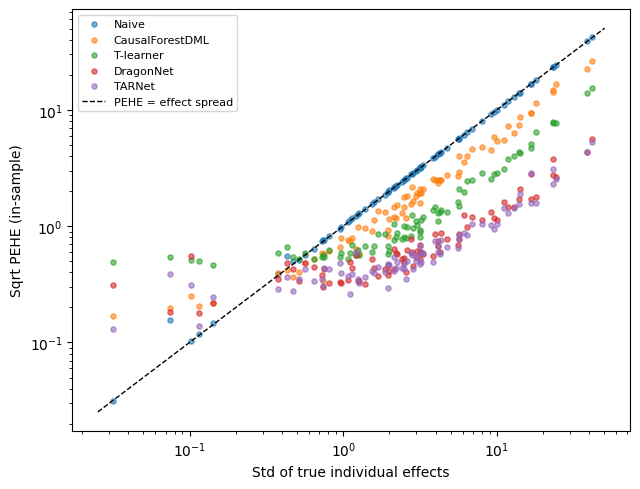

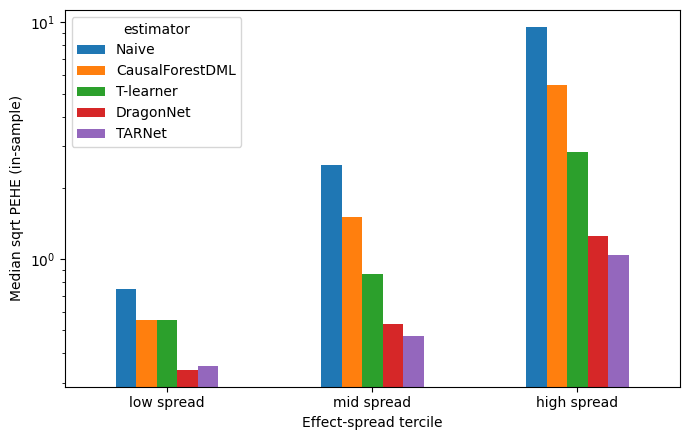

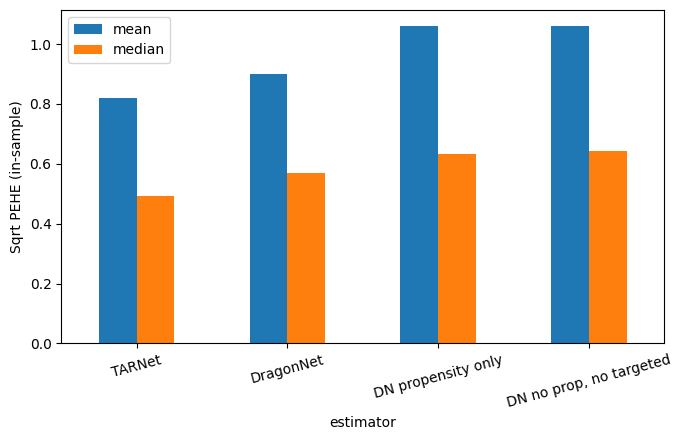

                pehe_in mean +/- 95% CI  pehe_in median  \
estimator                                                 
CausalForestDML         3.405 +/- 1.062           1.607   
DragonNet               0.901 +/- 0.204           0.571   
LinearDML               3.103 +/- 0.898           1.495   
Naive                   5.639 +/- 1.736           2.698   
T-learner               1.965 +/- 0.587           0.911   
TARNet                  0.819 +/- 0.191           0.491   

                pehe_out mean +/- 95% CI  pehe_out median  
estimator                                                  
CausalForestDML          3.605 +/- 1.229            1.678  
DragonNet                1.042 +/- 0.320            0.587  
LinearDML                3.157 +/- 0.921            1.659  
Naive                    5.736 +/- 1.882            2.744  
T-learner                2.663 +/- 0.937            1.183  
TARNet                   0.946 +/- 0.291            0.529  


In [33]:
import matplotlib.pyplot as plt

FIG_DIR = os.path.join(PROJECT_ROOT, "figures")
final = pd.read_csv(FINAL_PATH)
held = final[final["rep"] >= 20].copy()
held["spread"] = held["rep"].map(spread)
held["bin"] = held["rep"].map(bins)
models = ["Naive", "CausalForestDML", "T-learner", "DragonNet", "TARNet"]

# Figure 1: per-replication error against effect spread
fig, ax = plt.subplots(figsize=(6.5, 5))
for m in models:
    g = held[held["estimator"] == m]
    ax.scatter(g["spread"], g["pehe_in"], s=14, alpha=0.6, label=m)
lims = [held["spread"].min() * 0.8, held["spread"].max() * 1.2]
ax.plot(lims, lims, "k--", linewidth=1, label="PEHE = effect spread")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Std of true individual effects")
ax.set_ylabel("Sqrt PEHE (in-sample)")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "pehe_vs_spread.png"), dpi=200)
plt.show()

# Figure 2: median error per effect-spread tercile
med = held.groupby(["bin", "estimator"], observed=True)["pehe_in"].median().unstack()[models]
ax = med.plot(kind="bar", figsize=(7, 4.5), logy=True, rot=0)
ax.set_xlabel("Effect-spread tercile")
ax.set_ylabel("Median sqrt PEHE (in-sample)")
ax.figure.tight_layout()
ax.figure.savefig(os.path.join(FIG_DIR, "median_by_spread_bin.png"), dpi=200)
plt.show()

# Figure 3: DragonNet ablation next to TARNet
abl = pd.read_csv(ABL_PATH)
comb = pd.concat([abl, final[final["estimator"].isin(["DragonNet", "TARNet"])]], ignore_index=True)
comb = comb[comb["rep"] >= 20]
order = ["TARNet", "DragonNet", "DN propensity only", "DN no prop, no targeted"]
abl_stats = comb.groupby("estimator")["pehe_in"].agg(["mean", "median"]).loc[order]
ax = abl_stats.plot(kind="bar", figsize=(7, 4.5), rot=15)
ax.set_ylabel("Sqrt PEHE (in-sample)")
ax.figure.tight_layout()
ax.figure.savefig(os.path.join(FIG_DIR, "dragonnet_ablation.png"), dpi=200)
plt.show()

# Held-out results table
table_rows = []
for m, g in held.groupby("estimator"):
    mean_in, hw_in = mean_ci(g["pehe_in"])
    mean_out, hw_out = mean_ci(g["pehe_out"])
    table_rows.append({
        "estimator": m,
        "pehe_in mean +/- 95% CI": f"{mean_in:.3f} +/- {hw_in:.3f}",
        "pehe_in median": round(g["pehe_in"].median(), 3),
        "pehe_out mean +/- 95% CI": f"{mean_out:.3f} +/- {hw_out:.3f}",
        "pehe_out median": round(g["pehe_out"].median(), 3),
    })
results_table = pd.DataFrame(table_rows).set_index("estimator")
results_table.to_csv(os.path.join(PROJECT_ROOT, "results", "ihdp_heldout_table.csv"))
print(results_table)

In [34]:
D = 10
N_TRAIN = 2000
N_TEST = 500

def raw_effect_shape(X):
    return np.tanh(X[:, 0]) + 0.5 * X[:, 1] * X[:, 2] + 0.5 * (X[:, 3] > 0)

# Mean and std of the effect shape from a large reference sample
ref_X = np.random.default_rng(12345).standard_normal((200000, D))
ref_shape = raw_effect_shape(ref_X)
SHAPE_MEAN, SHAPE_STD = ref_shape.mean(), ref_shape.std()

def baseline_outcome(X):
    return 2 * X[:, 0] + X[:, 1] + 0.5 * X[:, 2] ** 2 + np.sin(X[:, 3])

def propensity(X, conf):
    score = 0.8 * X[:, 0] + 0.5 * X[:, 1] - 0.5 * X[:, 2] + 0.3 * X[:, 3]
    return np.clip(1 / (1 + np.exp(-conf * score)), 0.05, 0.95)

def true_cate(X, het):
    return 1.0 + het * (raw_effect_shape(X) - SHAPE_MEAN) / SHAPE_STD

def make_synthetic(seed, het, conf, n=N_TRAIN, n_test=N_TEST):
    rng = np.random.default_rng(seed)
    X = rng.standard_normal((n + n_test, D))
    tau = true_cate(X, het)
    t = rng.binomial(1, propensity(X, conf))
    y = baseline_outcome(X) + t * tau + rng.standard_normal(n + n_test)
    train = (X[:n], t[:n], y[:n], tau[:n])
    test = (X[n:], tau[n:])
    return train, test

In [35]:
HET_LEVELS = [0.5, 2.5, 8.0]
CONF_LEVELS = [0.5, 1.5]

check_rows = []
for het in HET_LEVELS:
    for conf in CONF_LEVELS:
        for seed in range(10):
            (X, t, y, tau), _ = make_synthetic(seed, het, conf)
            e = propensity(X, conf)
            check_rows.append({
                "het": het, "conf": conf,
                "tau_std": tau.std(),
                "ate": tau.mean(),
                "naive_bias": (y[t == 1].mean() - y[t == 0].mean()) - tau.mean(),
                "treated_frac": t.mean(),
                "frac_clipped": np.mean((e <= 0.05) | (e >= 0.95)),
            })

check = pd.DataFrame(check_rows)
print(check.groupby(["het", "conf"]).mean().round(3))

          tau_std    ate  naive_bias  treated_frac  frac_clipped
het conf                                                        
0.5 0.5     0.502  0.994       1.125         0.498          0.00
    1.5     0.502  0.994       2.425         0.500          0.08
2.5 0.5     2.508  0.971       1.429         0.498          0.00
    1.5     2.508  0.971       3.086         0.500          0.08
8.0 0.5     8.024  0.908       2.266         0.498          0.00
    1.5     8.024  0.908       4.904         0.500          0.08


In [36]:
with open(cfg_path) as f:
    frozen = json.load(f)

syn_builders = {
    "T-learner": lambda X, t, y, seed: build_tlearner_cfg(X, t, y, seed, **frozen["baselines"]["T-learner"]),
    "CausalForestDML": lambda X, t, y, seed: build_cf_cfg(X, t, y, seed, **frozen["baselines"]["CausalForestDML"]),
    "TARNet tuned": lambda X, t, y, seed: train_tarnet(X, t, y, seed, **frozen["neural"]["TARNet"]),
    "DragonNet tuned": lambda X, t, y, seed: train_dragonnet(X, t, y, seed, **frozen["neural"]["DragonNet"]),
    "TARNet default": lambda X, t, y, seed: train_tarnet(X, t, y, seed),
    "DragonNet default": lambda X, t, y, seed: train_dragonnet(X, t, y, seed),
}

def run_synthetic(name, builder, seed, het, conf):
    (X, t, y, tau), (X_te, tau_te) = make_synthetic(seed, het, conf)

    start = time.time()
    effect_fn = builder(X, t, y, seed)
    fit_seconds = time.time() - start

    tau_in = effect_fn(X)
    tau_out = effect_fn(X_te)

    return {
        "estimator": name, "het": het, "conf": conf, "seed": seed,
        "pehe_in": sqrt_pehe(tau_in, tau),
        "pehe_out": sqrt_pehe(tau_out, tau_te),
        "ate_err_in": ate_error(tau_in, tau),
        "seconds": fit_seconds,
    }

timing_rows = [run_synthetic(name, b, 0, 2.5, 1.5) for name, b in syn_builders.items()]
print(pd.DataFrame(timing_rows).round(3))

           estimator  het  conf  seed  pehe_in  pehe_out  ate_err_in  seconds
0          T-learner  2.5   1.5     0    1.733     1.643       0.772    1.128
1    CausalForestDML  2.5   1.5     0    1.344     1.337       0.231    3.544
2       TARNet tuned  2.5   1.5     0    1.145     1.171       0.352    7.685
3    DragonNet tuned  2.5   1.5     0    1.193     1.191       0.412   10.320
4     TARNet default  2.5   1.5     0    0.774     0.746       0.223    4.176
5  DragonNet default  2.5   1.5     0    0.714     0.704       0.008    6.000


In [37]:
SYN_PATH = os.path.join(PROJECT_ROOT, "results", "synthetic_results.csv")
SEEDS = range(5, 10)

if os.path.exists(SYN_PATH):
    syn_rows = pd.read_csv(SYN_PATH).to_dict("records")
else:
    syn_rows = []
syn_done = {(r["estimator"], r["het"], r["conf"], r["seed"]) for r in syn_rows}

for het in HET_LEVELS:
    for conf in CONF_LEVELS:
        for seed in SEEDS:
            for name, builder in syn_builders.items():
                if (name, het, conf, seed) in syn_done:
                    continue
                syn_rows.append(run_synthetic(name, builder, seed, het, conf))
                pd.DataFrame(syn_rows).to_csv(SYN_PATH, index=False)
        print("finished het", het, "conf", conf)

finished het 0.5 conf 0.5
finished het 0.5 conf 1.5
finished het 2.5 conf 0.5
finished het 2.5 conf 1.5
finished het 8.0 conf 0.5
finished het 8.0 conf 1.5


In [38]:
syn = pd.read_csv(SYN_PATH)

for col in ["pehe_in", "pehe_out"]:
    print(col)
    print(syn.pivot_table(index=["het", "conf"], columns="estimator", values=col, aggfunc="mean").round(3))

print(syn.groupby("estimator")["seconds"].mean().round(2))
print(syn.groupby(["het", "conf"]).size())

pehe_in
estimator  CausalForestDML  DragonNet default  DragonNet tuned  T-learner  \
het conf                                                                    
0.5 0.5              0.370              0.456            0.407      0.749   
    1.5              0.420              0.513            0.557      1.014   
2.5 0.5              1.365              0.781            1.261      1.279   
    1.5              1.418              0.785            1.266      1.673   
8.0 0.5              4.318              1.267            2.642      3.678   
    1.5              4.306              1.509            2.739      3.940   

estimator  TARNet default  TARNet tuned  
het conf                                 
0.5 0.5             0.439         0.391  
    1.5             0.498         0.454  
2.5 0.5             0.726         1.166  
    1.5             0.791         1.233  
8.0 0.5             1.208         2.194  
    1.5             1.359         2.622  
pehe_out
estimator  CausalForestDML  Dr

estimator  CausalForestDML  T-learner  TARNet tuned  TARNet default  \
het conf                                                              
0.5 0.5              0.370      0.749         0.391           0.439   
    1.5              0.420      1.014         0.454           0.498   
2.5 0.5              1.365      1.279         1.166           0.726   
    1.5              1.418      1.673         1.233           0.791   
8.0 0.5              4.318      3.678         2.194           1.208   
    1.5              4.306      3.940         2.622           1.359   

estimator  DragonNet tuned  DragonNet default  
het conf                                       
0.5 0.5              0.407              0.456  
    1.5              0.557              0.513  
2.5 0.5              1.261              0.781  
    1.5              1.266              0.785  
8.0 0.5              2.642              1.267  
    1.5              2.739              1.509  
estimator  CausalForestDML  T-learner  TARNet t

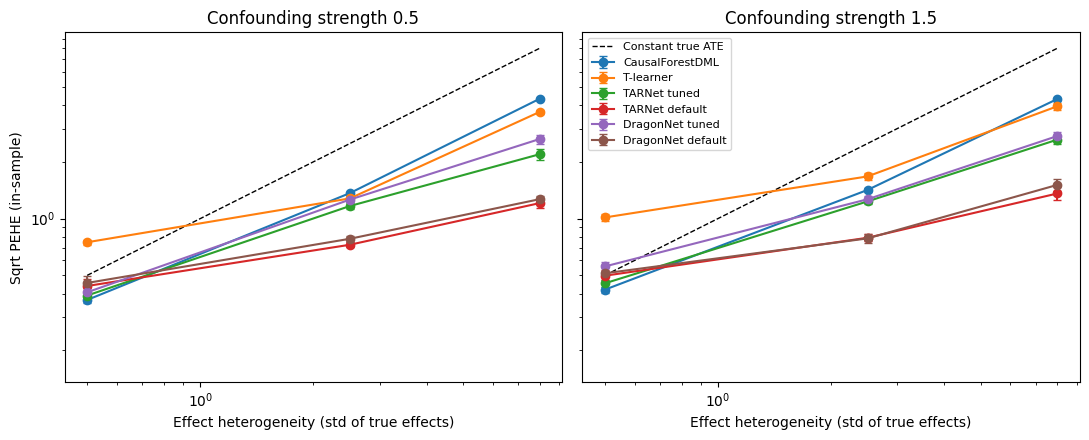

In [39]:
syn = pd.read_csv(SYN_PATH)
order = ["CausalForestDML", "T-learner", "TARNet tuned", "TARNet default",
         "DragonNet tuned", "DragonNet default"]

cell = syn.groupby(["het", "conf", "estimator"])["pehe_in"].agg(["mean", "median"]).unstack("estimator")
print(cell["mean"][order].round(3))
print(cell["median"][order].round(3))

ratio = syn.assign(ratio=syn["pehe_in"] / syn["het"])
print(ratio.pivot_table(index=["het", "conf"], columns="estimator",
                        values="ratio", aggfunc="mean")[order].round(2))

pairs = [("TARNet tuned", "TARNet default"), ("DragonNet tuned", "DragonNet default"),
         ("DragonNet default", "TARNet default"), ("TARNet default", "CausalForestDML"),
         ("TARNet tuned", "CausalForestDML")]

for (het, conf), g in syn.groupby(["het", "conf"]):
    wide_s = g.pivot(index="seed", columns="estimator", values="pehe_in")
    for a, b in pairs:
        diff = wide_s[a] - wide_s[b]
        print(het, conf, a, "vs", b, "| mean diff:", round(diff.mean(), 3),
              "| wins:", int((diff < 0).sum()), "of", len(diff))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)
for ax, conf in zip(axes, CONF_LEVELS):
    for name in order:
        g = syn[(syn["conf"] == conf) & (syn["estimator"] == name)].groupby("het")["pehe_in"]
        err = (1.96 * g.std() / np.sqrt(g.count())).values
        ax.errorbar(HET_LEVELS, g.mean().values, yerr=err, marker="o", capsize=3, label=name)
    ax.plot(HET_LEVELS, HET_LEVELS, "k--", linewidth=1, label="Constant true ATE")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Effect heterogeneity (std of true effects)")
    ax.set_title(f"Confounding strength {conf}")
axes[0].set_ylabel("Sqrt PEHE (in-sample)")
axes[1].legend(fontsize=8)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "synthetic_pehe_vs_het.png"), dpi=200)
plt.show()

In [40]:
SENS_PATH = os.path.join(PROJECT_ROOT, "results", "synthetic_sensitivity.csv")
sens_grid = [
    {"weight_decay": 1e-3, "rep_dim": 200},
    {"weight_decay": 1e-2, "rep_dim": 200},
    {"weight_decay": 3e-2, "rep_dim": 200},
    {"weight_decay": 1e-4, "rep_dim": 64},
    {"weight_decay": 1e-4, "rep_dim": 16},
]

if os.path.exists(SENS_PATH):
    sens_rows = pd.read_csv(SENS_PATH).to_dict("records")
else:
    sens_rows = []
sens_done = {(r["weight_decay"], r["rep_dim"], r["seed"]) for r in sens_rows}

for cfg in sens_grid:
    builder = lambda X, t, y, seed, c=cfg: train_tarnet(X, t, y, seed, **c)
    for seed in range(10):
        if (cfg["weight_decay"], cfg["rep_dim"], seed) in sens_done:
            continue
        row = run_synthetic("TARNet", builder, seed, 8.0, 1.5)
        row.update(cfg)
        sens_rows.append(row)
        pd.DataFrame(sens_rows).to_csv(SENS_PATH, index=False)

sens = pd.DataFrame(sens_rows)
print(sens.groupby(["weight_decay", "rep_dim"])["pehe_in"].mean().round(3))

syn = pd.read_csv(SYN_PATH)
ref = syn[(syn["het"] == 8.0) & (syn["conf"] == 1.5) & syn["estimator"].isin(["TARNet default", "TARNet tuned"])]
print(ref.groupby("estimator")["pehe_in"].mean().round(3))

weight_decay  rep_dim
0.0001        16         1.729
              64         1.413
0.0010        200        1.602
0.0100        200        2.633
0.0300        200        3.209
Name: pehe_in, dtype: float64
estimator
TARNet default    1.359
TARNet tuned      2.622
Name: pehe_in, dtype: float64


In [41]:
print(test_raw["x"].shape)

(75, 25, 100)


In [42]:
import sys
import numpy
import pandas
import scipy
import sklearn
import torch
import econml

versions = {
    "Python": sys.version.split()[0],
    "NumPy": numpy.__version__,
    "pandas": pandas.__version__,
    "SciPy": scipy.__version__,
    "scikit-learn": sklearn.__version__,
    "PyTorch": torch.__version__,
    "EconML": econml.__version__,
}

for name, version in versions.items():
    print(f"{name}: {version}")

Python: 3.13.15
NumPy: 2.1.3
pandas: 2.2.3
SciPy: 1.16.3
scikit-learn: 1.6.1
PyTorch: 2.11.0+cpu
EconML: 0.17.0


In [43]:
import os
import numpy as np
import pandas as pd
from scipy import stats

R = os.path.join(PROJECT_ROOT, "results")
final = pd.read_csv(os.path.join(R, "ihdp_final.csv"))
base = pd.read_csv(os.path.join(R, "ihdp_baselines.csv"))
abl = pd.read_csv(os.path.join(R, "ihdp_ablation.csv"))
syn = pd.read_csv(os.path.join(R, "synthetic_results.csv"))
sens = pd.read_csv(os.path.join(R, "synthetic_sensitivity.csv"))

def paired(wide, a, b):
    diff = wide[a] - wide[b]
    wins = int((diff < 0).sum())
    n = len(diff)
    return {"pair": f"{a} vs {b}",
            "mean diff": round(diff.mean(), 3),
            "median diff": round(diff.median(), 3),
            "a lower in": f"{wins} of {n}",
            "sign p": f"{stats.binomtest(wins, n, 0.5).pvalue:.2e}",
            "wilcoxon p": f"{stats.wilcoxon(diff).pvalue:.2e}"}

def header(text):
    print("\n" + "=" * 8, text, "=" * 8)

header("IHDP held-out table (reps 20-99)")
held = final[final["rep"] >= 20]
rows = []
for name, g in held.groupby("estimator"):
    m_in, h_in = mean_ci(g["pehe_in"])
    m_out, h_out = mean_ci(g["pehe_out"])
    rows.append({"estimator": name,
                 "in mean": m_in, "in ci": h_in, "in median": g["pehe_in"].median(),
                 "out mean": m_out, "out ci": h_out, "out median": g["pehe_out"].median()})
print(pd.DataFrame(rows).set_index("estimator").round(2))

header("IHDP held-out paired comparisons (in-sample)")
wide_h = held.pivot(index="rep", columns="estimator", values="pehe_in")
pairs_h = [("TARNet", "T-learner"), ("TARNet", "CausalForestDML"),
           ("DragonNet", "T-learner"), ("DragonNet", "CausalForestDML"),
           ("TARNet", "DragonNet")]
print(pd.DataFrame([paired(wide_h, a, b) for a, b in pairs_h]).to_string(index=False))

header("IHDP all 100 reps, tuned (in-sample)")
print(final.groupby("estimator")["pehe_in"].agg(["mean", "median"]).round(3).loc[["TARNet", "DragonNet"]])

header("TARNet at default settings, all 100 reps (in-sample)")
print(base[base["estimator"] == "TARNet"]["pehe_in"].agg(["mean", "median"]).round(3))

header("Effect-spread terciles (median in-sample)")
spread = pd.Series({rep: get_ihdp(rep, split="train")[3].std() for rep in range(100)})
bins = pd.qcut(spread, 3, labels=["low", "mid", "high"])
wide_base = base.pivot(index="rep", columns="estimator", values="pehe_in")
print("default settings, all 100 reps")
print(wide_base.groupby(bins, observed=True).median().round(3))
print("tuned, held-out reps")
print(wide_h.groupby(bins.reindex(wide_h.index), observed=True).median().round(3))

header("DragonNet ablation (reps 20-99)")
comb = pd.concat([abl,
                  final[final["estimator"] == "DragonNet"].assign(estimator="DN full"),
                  final[final["estimator"] == "TARNet"].assign(estimator="TARNet")], ignore_index=True)
comb = comb[comb["rep"] >= 20]
print(comb.groupby("estimator")[["pehe_in", "pehe_out"]].agg(["mean", "median"]).round(2))
wide_a = comb.pivot(index="rep", columns="estimator", values="pehe_in")
pairs_a = [("DN full", "DN no prop, no targeted"), ("DN full", "DN propensity only"),
           ("DN propensity only", "DN no prop, no targeted")]
print(pd.DataFrame([paired(wide_a, a, b) for a, b in pairs_a]).to_string(index=False))

header("Synthetic: mean in-sample sqrt PEHE per cell")
cell_in = syn.pivot_table(index=["het", "conf"], columns="estimator", values="pehe_in")
cell_out = syn.pivot_table(index=["het", "conf"], columns="estimator", values="pehe_out")
print(cell_in.round(3))
print("largest in-sample vs out-of-sample gap per estimator:")
print((cell_out - cell_in).abs().max().round(3))
print("fits per cell:", syn.groupby(["het", "conf"]).size().unique())

header("Synthetic: paired comparisons per cell (in-sample)")
pairs_s = [("TARNet tuned", "TARNet default"), ("DragonNet tuned", "DragonNet default"),
           ("DragonNet default", "TARNet default"), ("TARNet default", "CausalForestDML"),
           ("TARNet tuned", "CausalForestDML")]
for (het, conf), g in syn.groupby(["het", "conf"]):
    wide_s = g.pivot(index="seed", columns="estimator", values="pehe_in")
    out = pd.DataFrame([paired(wide_s, a, b) for a, b in pairs_s])[["pair", "mean diff", "a lower in", "sign p"]]
    print("het", het, "conf", conf)
    print(out.to_string(index=False))

header("Synthetic: effect of confounding and heterogeneity")
by_conf = cell_in.unstack("conf")
for name in ["T-learner", "TARNet default", "CausalForestDML"]:
    print(name, "change from conf 0.5 to 1.5, by het:")
    print((by_conf[name][1.5] - by_conf[name][0.5]).round(3))
print("T-learner error divided by het:")
print((cell_in["T-learner"] / cell_in.index.get_level_values("het").values).round(2))
print("growth in error from het 0.5 to 8 at conf 0.5:")
print((cell_in.loc[(8.0, 0.5)] / cell_in.loc[(0.5, 0.5)]).round(2))

header("Sensitivity at het 8.0, conf 1.5 (TARNet, mean in-sample)")
print(sens.groupby(["weight_decay", "rep_dim"])["pehe_in"].mean().round(3))
ref = syn[(syn["het"] == 8.0) & (syn["conf"] == 1.5) & syn["estimator"].isin(["TARNet default", "TARNet tuned"])]
print(ref.groupby("estimator")["pehe_in"].mean().round(3))


======== IHDP held-out table (reps 20-99) ========
                 in mean  in ci  in median  out mean  out ci  out median
estimator                                                               
CausalForestDML     3.41   1.06       1.61      3.60    1.23        1.68
DragonNet           0.90   0.20       0.57      1.04    0.32        0.59
LinearDML           3.10   0.90       1.50      3.16    0.92        1.66
Naive               5.64   1.74       2.70      5.74    1.88        2.74
T-learner           1.97   0.59       0.91      2.66    0.94        1.18
TARNet              0.82   0.19       0.49      0.95    0.29        0.53

======== IHDP held-out paired comparisons (in-sample) ========
                        pair  mean diff  median diff a lower in   sign p wilcoxon p
         TARNet vs T-learner     -1.146       -0.457   79 of 80 1.34e-22   8.15e-15
   TARNet vs CausalForestDML     -2.586       -1.122   77 of 80 1.41e-19   2.01e-14
      DragonNet vs T-learner     -1.064       -0

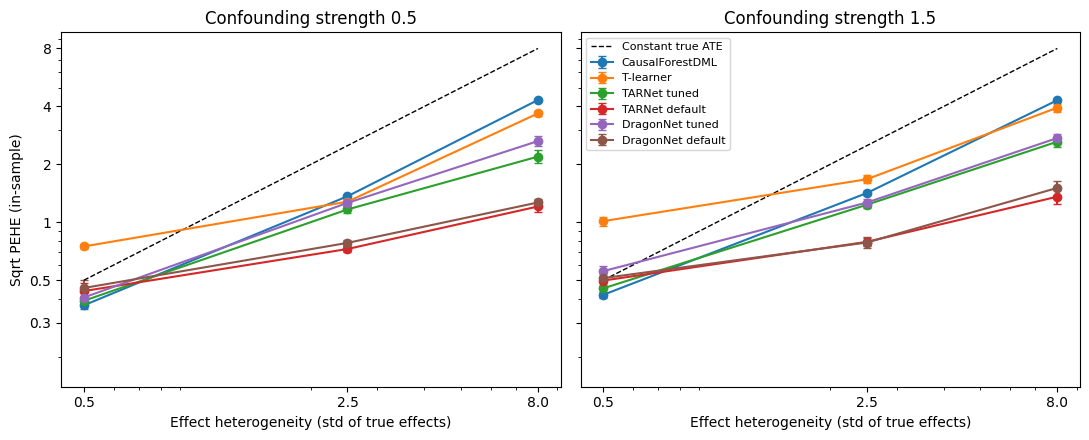

In [44]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import NullFormatter
from scipy import stats

HET_LEVELS = [0.5, 2.5, 8.0]
CONF_LEVELS = [0.5, 1.5]
FIG_DIR = os.path.join(PROJECT_ROOT, "figures")
syn = pd.read_csv(os.path.join(PROJECT_ROOT, "results", "synthetic_results.csv"))

order = ["CausalForestDML", "T-learner", "TARNet tuned", "TARNet default",
         "DragonNet tuned", "DragonNet default"]
y_ticks = [0.3, 0.5, 1, 2, 4, 8]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)
for ax, conf in zip(axes, CONF_LEVELS):
    for name in order:
        g = syn[(syn["conf"] == conf) & (syn["estimator"] == name)].groupby("het")["pehe_in"]
        n = g.count()
        err = (stats.t.ppf(0.975, (n - 1).values) * g.std() / np.sqrt(n)).values
        ax.errorbar(HET_LEVELS, g.mean().values, yerr=err, marker="o", capsize=3, label=name)
    ax.plot(HET_LEVELS, HET_LEVELS, "k--", linewidth=1, label="Constant true ATE")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xticks(HET_LEVELS)
    ax.set_xticklabels(HET_LEVELS)
    ax.set_yticks(y_ticks)
    ax.set_yticklabels(y_ticks)
    ax.xaxis.set_minor_formatter(NullFormatter())
    ax.yaxis.set_minor_formatter(NullFormatter())
    ax.set_xlabel("Effect heterogeneity (std of true effects)")
    ax.set_title(f"Confounding strength {conf}")
axes[0].set_ylabel("Sqrt PEHE (in-sample)")
axes[1].legend(fontsize=8)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "synthetic_pehe_vs_het.png"), dpi=200)
plt.show()

In [45]:
x = train_raw["x"]
t = train_raw["t"]

same_x = all(np.array_equal(x[:, :, 0], x[:, :, k]) for k in range(1, 100))
same_t = all(np.array_equal(t[:, 0], t[:, k]) for k in range(1, 100))

print("covariates identical across replications:", same_x)
print("treatment identical across replications:", same_t)

covariates identical across replications: False
treatment identical across replications: False


In [46]:
def pooled(rep):
    x = np.concatenate([train_raw["x"][:, :, rep], test_raw["x"][:, :, rep]], axis=0)
    t = np.concatenate([train_raw["t"][:, rep], test_raw["t"][:, rep]], axis=0)
    return x, t

def sorted_rows(a):
    return a[np.lexsort(a.T[::-1])]

x0, t0 = pooled(0)
ref_x = sorted_rows(x0)
ref_xt = sorted_rows(np.column_stack([x0, t0]))

same_x, same_xt = [], []
for k in range(1, 100):
    xk, tk = pooled(k)
    same_x.append(np.array_equal(ref_x, sorted_rows(xk)))
    same_xt.append(np.array_equal(ref_xt, sorted_rows(np.column_stack([xk, tk]))))

print("units per replication (train + test):", len(x0))
print("pooled covariates identical across replications:", all(same_x))
print("pooled covariates and treatment identical across replications:", all(same_xt))

units per replication (train + test): 747
pooled covariates identical across replications: True
pooled covariates and treatment identical across replications: True
